# Notebook de pruebas: evaluación de modelos candidatos para clasificación de grado KL (KODA)

**Propósito:** este notebook prueba de forma independiente varios modelos de clasificación de osteoartritis de rodilla (candidatos externos, entrenados previamente por terceros en Kaggle) para decidir cuál se integrará como *Motor de Inferencia de IA* del proyecto **KODA**.

Para cada modelo candidato se evalúan tres cosas:
1. **Carga:** si el modelo y sus pesos se pueden cargar correctamente en este entorno.
2. **Inferencia:** si genera predicciones de grado KL (0 a 4) sobre una muestra de radiografías.
3. **Grad-CAM:** si se puede generar el mapa de calor de interpretabilidad que exige KODA.

Los resultados de cada modelo se registran con una función `registrar_resultado(...)` (definida en una celda anterior no incluida en este archivo — ver nota al final) y se consolidan al final en un `DataFrame` que se exporta a `resultados_pruebas_modelos.csv`.

## 1. Importación de librerías base
Librerías generales para manejo de arreglos, dataframes, rutas de archivos y graficación.

In [234]:
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

## 2. Descarga del dataset Knee OA (Kaggle)
Se descarga el dataset público `tommyngx/kneeoa` mediante `kagglehub`, que ya viene organizado en carpetas por *split* (`train`, `val`, `test`, `auto_test`).

In [235]:
import kagglehub

DATASET_DIR = kagglehub.dataset_download("tommyngx/kneeoa")
print("Path to dataset files:", DATASET_DIR)

for item in os.listdir(DATASET_DIR):
    print(" -", item)

Path to dataset files: /kaggle/input/datasets/tommyngx/kneeoa
 - auto_test
 - val
 - test
 - train


### 2.1 Selección y exploración del split a usar
Se define el split a usar para las pruebas (`test` por defecto) y se listan sus subcarpetas, que corresponden a las clases de grado KL (`0` a `4`).

In [236]:
SAMPLE_SIZE = 30
IMG_SIZE = (224, 224)
CLASS_NAMES = ["0", "1", "2", "3", "4"]
SPLIT_A_USAR = "test"  # train / val / test / auto_test

split_dir = os.path.join(DATASET_DIR, SPLIT_A_USAR)
print("Contenido de", split_dir, ":")
if os.path.isdir(split_dir):
    for item in os.listdir(split_dir):
        print(" -", item)
else:
    print("Ojo: revisa el nombre real de la carpeta de split")

Contenido de /kaggle/input/datasets/tommyngx/kneeoa/test :
 - 2
 - 0
 - 3
 - 1
 - 4


### 2.2 Muestreo aleatorio de imágenes de prueba
Se recolectan todas las imágenes del split seleccionado y se toma una muestra aleatoria reproducible (`seed=42`) de `SAMPLE_SIZE` imágenes. Esta misma muestra (`sample_paths`) es la que se reutiliza más adelante para probar cada uno de los modelos candidatos, de modo que todos se evalúen sobre las mismas imágenes.

Total imágenes encontradas en 'test': 1656


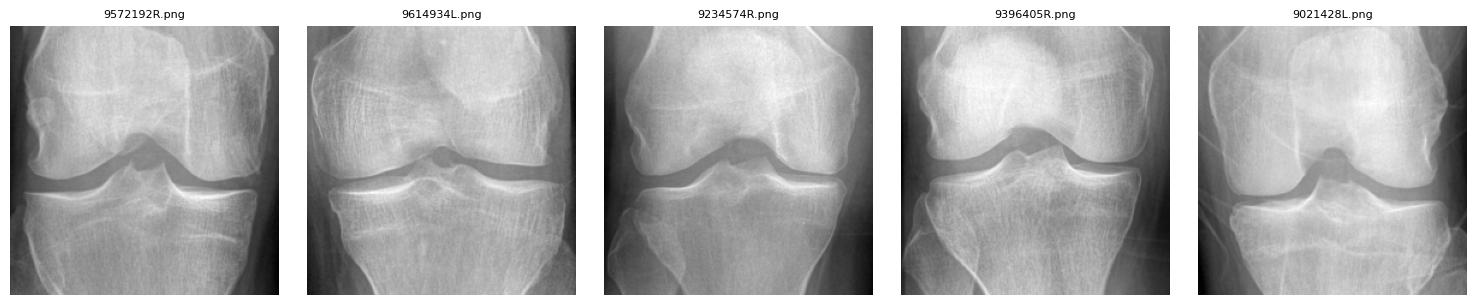

In [237]:
all_images = glob.glob(os.path.join(split_dir, "**", "*.*"), recursive=True)
all_images = [p for p in all_images if p.lower().endswith((".png", ".jpg", ".jpeg"))]
print(f"Total imágenes encontradas en '{SPLIT_A_USAR}': {len(all_images)}")

np.random.seed(42)
sample_paths = list(np.random.choice(all_images, size=min(SAMPLE_SIZE, len(all_images)), replace=False))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, p in zip(axes, sample_paths[:5]):
    img = plt.imread(p)
    ax.imshow(img, cmap="gray")
    ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.3 Inventario de archivos disponibles en el entorno
Recorre `/kaggle/input` e imprime todos los archivos disponibles (datasets y notebooks de origen de los modelos candidatos), útil para ubicar rutas de pesos/checkpoints.

In [238]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/DIKO.pth
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__results__.html
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/DIKO_log.json
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__notebook__.ipynb
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__output__.json
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/custom.css
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__results___files/__results___1_0.png
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__results___files/__results___13_3.png
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__results___files/__results___10_0.png
/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/__results___files/__results___12_0.png
/kaggle/input/notebooks/abdallahabdallahatef/knee-osteoarthritis-classfication-cnn-83/__results__.h

## 3. Modelo 2 — DIKO_Stage2 (DenseNet201 + InceptionV3)
### 3.1 Definición de la arquitectura y carga del checkpoint
Se define en PyTorch la arquitectura `DIKO_Stage2`: combina características extraídas por `DenseNet201` y por `InceptionV3` (ambos preentrenados en ImageNet), las concatena y las pasa por una cabeza totalmente conectada (`fc1` → `fc2` → `output`) para clasificar entre los 5 grados KL.

Luego se carga el checkpoint completo (`DIKO.pth`) con `weights_only=False` y se valida que el objeto cargado sea efectivamente una instancia de `DIKO_Stage2` ya entrenada.

In [239]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

class DIKO_Stage2(nn.Module):
    def __init__(self, num_classes=5):
        super(DIKO_Stage2, self).__init__()
        self.num_classes = num_classes

        self.densenet201 = models.densenet201(weights='IMAGENET1K_V1')
        self.densenet201_features_dim = self.densenet201.classifier.in_features

        self.inception_v3 = models.inception_v3(weights='IMAGENET1K_V1')
        self.inception_features_dim = self.inception_v3.fc.in_features
        self.inception_v3.fc = nn.Identity()

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc0_densenet = nn.Linear(self.densenet201_features_dim, 1000)
        self.fc0_inception = nn.Linear(self.inception_features_dim, 1000)

        self.dropout0 = nn.Dropout(p=0.2)
        self.fc1 = nn.Linear(2000, 512)
        self.dropout1 = nn.Dropout(p=0.1)

        self.fc2 = nn.Linear(512, 128)
        self.dropout2 = nn.Dropout(p=0.1)

        self.output = nn.Linear(128, num_classes)

    def forward(self, x):
        densenet_features = self.densenet201.features(x)
        inception_features = self.inception_v3(x)
        if isinstance(inception_features, tuple):
            inception_features = inception_features[0]

        densenet_features = self.avgpool(densenet_features)

        densenet_features = densenet_features.view(densenet_features.size(0), -1)
        inception_features = inception_features.view(inception_features.size(0), -1)

        densenet_features = self.fc0_densenet(densenet_features)
        inception_features = self.fc0_inception(inception_features)
        densenet_features = self.dropout0(densenet_features)
        inception_features = self.dropout0(inception_features)

        combined_features = torch.cat((densenet_features, inception_features), 1)

        out = F.relu(self.fc1(combined_features))
        out = self.dropout1(out)
        out = F.relu(self.fc2(out))
        out = self.dropout2(out)
        output = self.output(out)
        return output


DIKO_WEIGHTS_PATH = "/kaggle/input/notebooks/tahpvm/knee-osteoarthritis-classification/DIKO.pth"

checkpoint = torch.load(DIKO_WEIGHTS_PATH, map_location="cpu", weights_only=False)
print("Tipo de objeto cargado:", type(checkpoint))

if isinstance(checkpoint, DIKO_Stage2):
    model_2 = checkpoint
    model_2.eval()
    print("Modelo 2 (DIKO_Stage2) cargado y listo para inferencia.")
else:
    print("No era un objeto DIKO_Stage2 directo, revisar estructura:", checkpoint)

Tipo de objeto cargado: <class '__main__.DIKO_Stage2'>
Modelo 2 (DIKO_Stage2) cargado y listo para inferencia.


### 3.2 Preprocesamiento e inferencia sobre la muestra
Se define el pipeline de preprocesamiento esperado por este modelo (resize a 299×299 + normalización con las medias/desviaciones estándar de ImageNet) y se ejecuta la inferencia sobre las imágenes de `sample_paths`, guardando el grado KL predicho para cada una en `predicciones_2`.

In [240]:
import torchvision.transforms as transforms
from PIL import Image

diko_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

predicciones_2 = []
with torch.no_grad():
    for p in sample_paths:
        img = Image.open(p).convert("RGB")
        x = diko_transform(img).unsqueeze(0)
        logits = model_2(x)
        pred_class = torch.argmax(logits, dim=1).item()
        predicciones_2.append({"imagen": os.path.basename(p), "grado_KL_predicho": pred_class})

for pred in predicciones_2[:10]:
    print(pred)

salida_muestra_2 = f"OK — {len(predicciones_2)} predicciones generadas sobre la muestra"

{'imagen': '9572192R.png', 'grado_KL_predicho': 0}
{'imagen': '9614934L.png', 'grado_KL_predicho': 1}
{'imagen': '9234574R.png', 'grado_KL_predicho': 0}
{'imagen': '9396405R.png', 'grado_KL_predicho': 0}
{'imagen': '9021428L.png', 'grado_KL_predicho': 0}
{'imagen': '9910787L.png', 'grado_KL_predicho': 0}
{'imagen': '9579246R.png', 'grado_KL_predicho': 0}
{'imagen': '9453074L.png', 'grado_KL_predicho': 1}
{'imagen': '9392060R.png', 'grado_KL_predicho': 0}
{'imagen': '9281025L.png', 'grado_KL_predicho': 0}


### 3.3 Registro preliminar de resultados
Se registra un primer resultado para el Modelo 2: carga e inferencia exitosas, pero con Grad-CAM aún **pendiente** (se completa más adelante, en la sección 6).

In [241]:
resultados = []
MODELO_2_NOMBRE = "DIKO_Stage2 (DenseNet201 + InceptionV3)"

registrar_resultado(
    nombre_modelo=MODELO_2_NOMBRE,
    responsable="TODO",
    carga_ok="OK — modelo completo cargado con weights_only=False",
    salida_muestra=f"OK — {len(predicciones_2)} predicciones generadas. Ejemplo: {predicciones_2[:5]}",
    gradcam_ok="Pendiente",
    observaciones="Preprocesamiento: Resize(299,299) + Normalize ImageNet, según notebook original",
)

Registrado: DIKO_Stage2 (DenseNet201 + InceptionV3)


## 4. Modelo 3 — CNN personalizada (Conv2D + ELU + MaxPool)
### 4.1 Construcción y carga de pesos
Se instancia `model_3` (arquitectura definida previamente como `mymodel()`, fuera de este notebook) y se "construye" pasándole un tensor de entrada ficticio (`dummy_input`) con la forma esperada `(batch, alto=244, ancho=224, canales=1)` — esto es necesario en Keras subclassed models antes de poder cargar pesos con `load_weights`. Después se cargan los pesos entrenados desde `CNN_MODEL_PATH` y se imprime el resumen de la arquitectura.

In [242]:
import tensorflow as tf

model_3 = mymodel()
dummy_input = tf.zeros((1, 244, 224, 1))  # (batch, alto, ancho, canales=escala de grises)
_ = model_3(dummy_input)  # esto "construye" las capas internas

model_3.load_weights(CNN_MODEL_PATH)
print("Modelo 3 cargado y construido correctamente.")
model_3.summary()

Modelo 3 cargado y construido correctamente.


Model: "mymodel_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (1, 244, 224, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_65 (ELU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (1, 122, 112, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (1, 122, 112, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_66 (ELU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (1, 61, 56, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_67 (ELU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (1, 107520)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (1, 128)               │    13,762,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_68 (ELU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_69 (ELU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (1, 5)                 │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,864,197 (52.89 MB)

 Trainable params: 13,864,069 (52.89 MB)

 Non-trainable params: 128 (512.00 B)

### 4.2 Preprocesamiento e inferencia sobre la muestra
Se preprocesan las imágenes de la muestra a escala de grises, se redimensionan a `(224, 244)` (ancho × alto, como espera PIL) y se normalizan a `[0, 1]`. Se ejecuta la inferencia y se guarda el grado KL predicho para cada imagen en `predicciones_3`.

In [243]:
import numpy as np
from PIL import Image

predicciones_3 = []
for p in sample_paths:
    img = Image.open(p).convert("L")  # escala de grises
    img = img.resize((224, 244))  # PIL usa (ancho, alto)
    arr = np.array(img).astype("float32") / 255.0
    arr = arr.reshape(1, 244, 224, 1)  # (batch, alto, ancho, canal)
    logits = model_3(arr, training=False)
    pred_class = int(tf.argmax(logits, axis=1).numpy()[0])
    predicciones_3.append({"imagen": os.path.basename(p), "grado_KL_predicho": pred_class})

for pred in predicciones_3[:10]:
    print(pred)

salida_muestra_3 = f"OK — {len(predicciones_3)} predicciones generadas sobre la muestra"

{'imagen': '9572192R.png', 'grado_KL_predicho': 2}
{'imagen': '9614934L.png', 'grado_KL_predicho': 2}
{'imagen': '9234574R.png', 'grado_KL_predicho': 0}
{'imagen': '9396405R.png', 'grado_KL_predicho': 0}
{'imagen': '9021428L.png', 'grado_KL_predicho': 0}
{'imagen': '9910787L.png', 'grado_KL_predicho': 1}
{'imagen': '9579246R.png', 'grado_KL_predicho': 4}
{'imagen': '9453074L.png', 'grado_KL_predicho': 2}
{'imagen': '9392060R.png', 'grado_KL_predicho': 0}
{'imagen': '9281025L.png', 'grado_KL_predicho': 0}


### 4.3 Registro de resultados
Se registra el resultado del Modelo 3: carga e inferencia exitosas (Grad-CAM aún pendiente en este punto). En observaciones se anota que el modelo mostró sobreajuste durante el entrenamiento original (56.57% de exactitud en validación), lo cual es relevante para interpretar la confiabilidad de sus predicciones.

In [244]:
registrar_resultado(
    nombre_modelo=MODELO_3_NOMBRE,
    responsable="TODO",
    carga_ok="OK — modelo reconstruido (build + load_weights) tras corregir __init__ y layer count",
    salida_muestra=f"OK — {len(predicciones_3)} predicciones generadas. Ejemplo: {predicciones_3[:5]}",
    gradcam_ok="Pendiente",
    observaciones="Preprocesamiento: escala de grises, resize 224x244 (ancho x alto), normalización /255. Coincide con overfitting reportado en Sección 1 (val 56.57%) — revisar si predicciones son confiables.",
)

Registrado: CNN personalizada (3 bloques Conv2D+ELU+MaxPool, sin transfer learning)


## 5. Modelo 4 — MobileNetV3Large (clasificación binaria Normal/OA)
### 5.1 Inspección del código fuente original
Antes de reconstruir la arquitectura, se imprime el contenido del script `helper_functions.py` del notebook original del autor, para entender cómo definió y entrenó el modelo.

In [245]:
with open("/kaggle/input/notebooks/vencerlanz09/osteoarthritis-classification-using-mobilenetv3/helper_functions.py") as f:
    print(f.read())

### We create a bunch of helpful functions throughout the course.
### Storing them here so they're easily accessible.

import tensorflow as tf

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224, scale=True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into
  (224, 224, 3).

  Parameters
  ----------
  filename (str): string filename of target image
  img_shape (int): size to resize target image to, default 224
  scale (bool): whether to scale pixel values to range(0, 1), default True
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.image.decode_jpeg(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    # Rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img

# Note: The following confusion matrix code is a remix of Scikit-Learn's 
# plo

### 5.2 Reconstrucción de la arquitectura (código de referencia, comentado)
Bloque comentado (código de referencia, no ejecutado) que documenta cómo se reconstruiría `model_4`: un `MobileNetV3Large` preentrenado (sin pesos, congelado) más una cabeza densa personalizada con salida binaria (`Normal` vs `OA`). Se deja comentado porque la reconstrucción real y la carga de pesos se intentan en las celdas siguientes.

In [246]:
##import tensorflow as tf
##from tensorflow.keras.layers import Dense, Dropout
##from tensorflow.keras import Model

##MODELO_4_NOMBRE = "MobileNetV3Large (ImageNet + cabeza densa, binario Normal/OA)"

##pretrained_model = tf.keras.applications.MobileNetV3Large(
   ## input_shape=(224, 224, 3),
   ## include_top=False,
  ##  weights=None,  # vamos a cargar los pesos propios enseguida, no hace falta bajar ImageNet
   ## pooling='avg')
##pretrained_model.trainable = False

##inputs = pretrained_model.input
##x = Dense(256, activation='relu')(pretrained_model.output)
##x = Dropout(0.2)(x)
#x = Dense(256, activation='relu')(x)
#x = Dropout(0.2)(x)
#outputs = Dense(2, activation='softmax')(x)

#model_4 = Model(inputs=inputs, outputs=outputs)

#MOBILENET_CKPT_PREFIX = "/kaggle/input/notebooks/vencerlanz09/osteoarthritis-classification-using-mobilenetv3/bones_classification_model_checkpoint"
#model_4.load_weights(MOBILENET_CKPT_PREFIX)
#print("Modelo 4 cargado.")

### 5.3 Primer intento de restauración de pesos vía checkpoint
Se intenta restaurar los pesos del Modelo 4 usando `tf.train.Checkpoint`, apuntando al prefijo del checkpoint original (`MOBILENET_CKPT_PREFIX`). Se usa `expect_partial()` para no lanzar error inmediato si no todas las variables coinciden.

In [247]:
checkpoint = tf.train.Checkpoint(model=model_4)
status = checkpoint.restore(MOBILENET_CKPT_PREFIX)
status.expect_partial()
print("Restauración intentada. Revisa si hay warnings arriba.")

Restauración intentada. Revisa si hay warnings arriba.


### 5.4 Verificación de la restauración: predicción y coincidencia de variables
Se preprocesa una imagen de muestra (resize 224×224, RGB) y se ejecuta una predicción con `model_4` para ver si los pesos cargados producen una salida razonable. Luego se repite la restauración del checkpoint, pero esta vez validando explícitamente con `assert_existing_objects_matched()` y `assert_consumed()` si todas las variables del checkpoint lograron emparejarse con las del modelo reconstruido — esto ayuda a diagnosticar la incompatibilidad de versiones detectada con este modelo.

In [248]:
import numpy as np
from PIL import Image

img = Image.open(sample_paths[0]).convert("RGB").resize((224, 224))
arr = np.array(img).astype("float32")
arr = np.expand_dims(arr, axis=0)  # (1, 224, 224, 3)

pred = model_4.predict(arr)
print("Predicción cruda:", pred)
checkpoint = tf.train.Checkpoint(model=model_4)
status = checkpoint.restore(MOBILENET_CKPT_PREFIX)

try:
    status.assert_existing_objects_matched()
    print("Coincidencia con objetos existentes: OK")
except AssertionError as e:
    print("No coincidieron variables:", e)

try:
    status.assert_consumed()
    print("Todas las variables del checkpoint fueron consumidas: OK")
except AssertionError as e:
    print("Quedaron variables del checkpoint sin usar:", e)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicción cruda: [[0.5 0.5]]
No coincidieron variables: Found 269 Python objects that were not bound to checkpointed values, likely due to changes in the Python program. Showing 10 of 269 unmatched objects: [<Variable path=expanded_conv_11_depthwise_bn/gamma, shape=(672,), dtype=float32, value=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1

### 5.5 Segundo intento de restauración (usando `root=` en vez de `model=`)
Se repite la restauración del checkpoint cambiando el argumento de `tf.train.Checkpoint` de `model=model_4` a `root=model_4`, para descartar si el problema de restauración se debía a la forma en que se declaró el checkpoint, y se vuelve a probar la predicción sobre la misma imagen.

In [249]:
checkpoint = tf.train.Checkpoint(root=model_4)
status = checkpoint.restore(MOBILENET_CKPT_PREFIX)
status.expect_partial()

# Volver a probar predicción
pred = model_4.predict(arr)
print("Predicción cruda (con root=):", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicción cruda (con root=): [[0.5 0.5]]


## 6. Grad-CAM manual para el Modelo 2 (DIKO_Stage2)
Como este modelo combina dos backbones, Grad-CAM se implementa manualmente (sin librerías externas como `pytorch-grad-cam`) usando *hooks* de PyTorch:
- Un **forward hook** sobre `model_2.densenet201.features` guarda las activaciones de esa capa.
- Un **backward hook** sobre la misma capa guarda los gradientes durante la retropropagación.

Para 3 imágenes de la muestra se calcula la predicción, se retropropaga el score de la clase predicha, se ponderan las activaciones por el promedio de sus gradientes (fórmula estándar de Grad-CAM) y se genera el mapa de calor, que luego se redimensiona y se superpone sobre la imagen original para visualizarlo.

/tmp/ipykernel_174/75606027.py:31: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


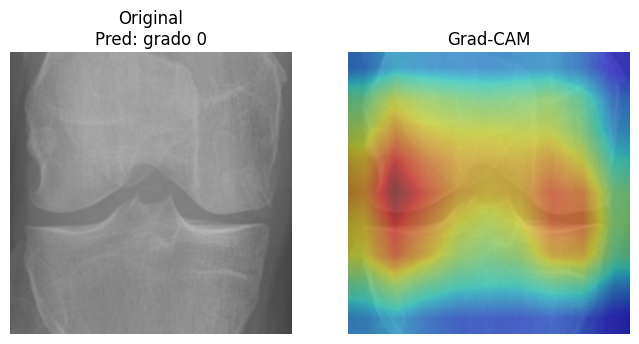

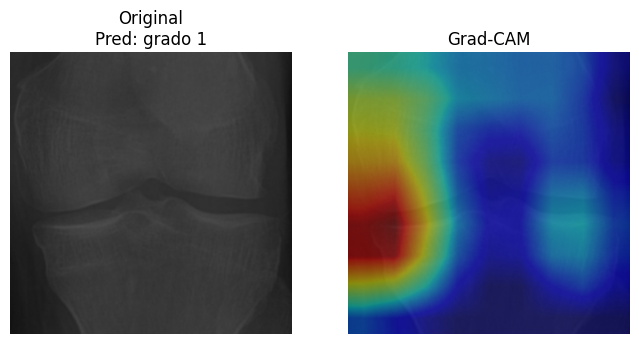

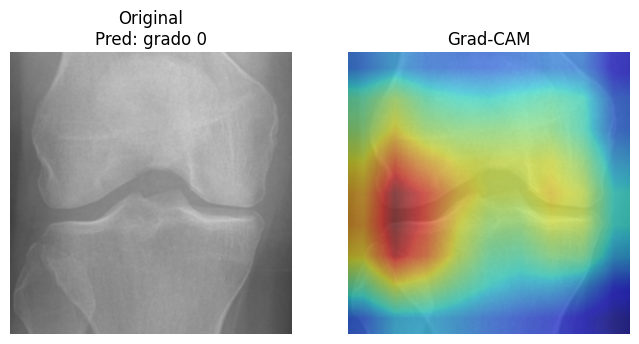

In [250]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

target_layer = model_2.densenet201.features

activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations['value'] = output

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0]

h1 = target_layer.register_forward_hook(forward_hook)
h2 = target_layer.register_full_backward_hook(backward_hook)

for p in sample_paths[:3]:
    img = Image.open(p).convert("RGB")
    img_resized = img.resize((299, 299))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0

    input_tensor = diko_transform(img).unsqueeze(0)

    model_2.zero_grad()
    output = model_2(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()
    score = output[0, pred_class]
    score.backward()

    acts = activations['value'][0]   # (C, H, W)
    grads = gradients['value'][0]    # (C, H, W)

    weights = grads.mean(dim=(1, 2))
    cam = torch.zeros(acts.shape[1:], dtype=torch.float32)
    for i, w in enumerate(weights):
        cam += w * acts[i]
    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)
    cam = cam.detach().numpy()

    cam_resized = cv2.resize(cam, (299, 299))
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = 0.5 * rgb_img + 0.5 * heatmap

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original\nPred: grado {pred_class}")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")
    plt.show()

h1.remove()
h2.remove()

gradcam_ok_2 = "OK — Grad-CAM implementado manualmente (sin librerías externas) sobre densenet201.features"

### 6.1 Registro de resultados actualizado (Grad-CAM confirmado)
Se vuelve a registrar el resultado del Modelo 2, ahora marcando Grad-CAM como exitoso y anotando que los mapas de calor resultantes se concentran en los bordes articulares, lo cual es clínicamente coherente con lo que un radiólogo esperaría ver.

In [251]:
registrar_resultado(
    nombre_modelo=MODELO_2_NOMBRE,
    responsable="TODO",
    carga_ok="OK — modelo completo cargado con weights_only=False",
    salida_muestra=f"OK — {len(predicciones_2)} predicciones generadas. Ejemplo: {predicciones_2[:5]}",
    gradcam_ok="OK — Grad-CAM implementado manualmente sobre densenet201.features, resultados clínicamente coherentes (se enfoca en bordes articulares)",
    observaciones="Preprocesamiento: Resize(299,299) + Normalize ImageNet, según notebook original",
)

Registrado: DIKO_Stage2 (DenseNet201 + InceptionV3)


## 7. Grad-CAM manual para el Modelo 3 (CNN personalizada)
Como `model_3` es un modelo *subclassed* de Keras (no funcional), Grad-CAM se implementa manualmente reproduciendo el forward pass capa por capa dentro de un `tf.GradientTape`, hasta la última capa convolucional con activación (`a3`), que es la que se usa como mapa de activaciones. Se calculan los gradientes de la clase predicha respecto a `a3`, se promedian espacialmente y se combinan con las activaciones para producir el heatmap, que se superpone sobre 3 imágenes de muestra.

El patrón resultante se describe como más disperso/ruidoso que el del Modelo 2, consistente con el sobreajuste detectado previamente para este modelo.

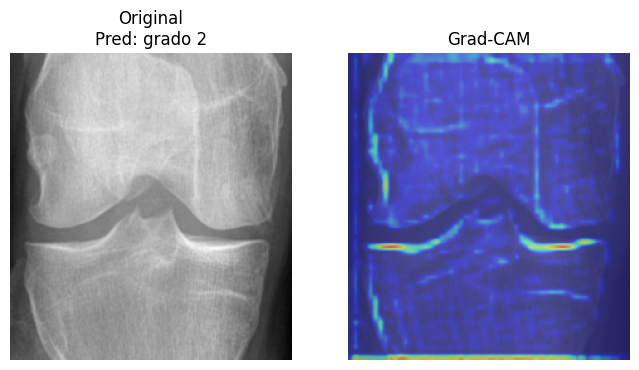

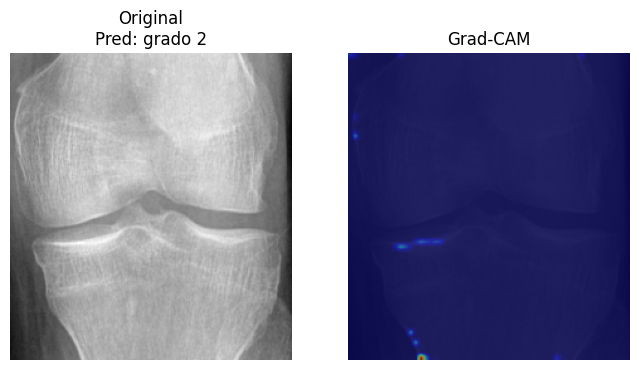

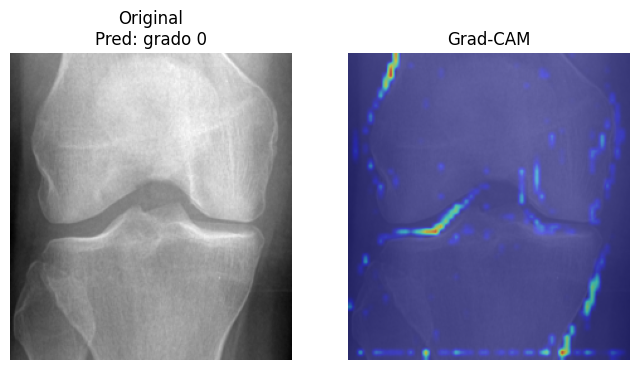

In [252]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

def grad_cam_modelo3(model, img_array):
    with tf.GradientTape() as tape:
        x = tf.convert_to_tensor(img_array)
        c1 = model.c1(x); a1 = model.a1(c1); p1 = model.p1(a1)
        c2 = model.c2(p1); b2 = model.b2(c2); a2 = model.a2(b2); p2 = model.p2(a2)
        c3 = model.c3(p2)
        a3 = model.a3(c3)  # última capa conv con activación, antes del pooling final
        tape.watch(a3)
        p3 = model.p3(a3)
        f = model.f(p3)
        d1 = model.d1(f); ad1 = model.ad1(d1)
        d2 = model.d2(ad1); ad2 = model.ad2(d2)
        preds = model.out(ad2)
        class_index = tf.argmax(preds[0])
        class_channel = preds[:, class_index]

    grads = tape.gradient(class_channel, a3)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(a3[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(class_index.numpy())


for p in sample_paths[:3]:
    img = Image.open(p).convert("L").resize((224, 244))
    arr = np.array(img).astype("float32") / 255.0
    arr_input = arr.reshape(1, 244, 224, 1)

    heatmap, pred_class = grad_cam_modelo3(model_3, arr_input)

    heatmap_resized = cv2.resize(heatmap, (224, 244))
    heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]
    rgb_img = np.stack([arr]*3, axis=-1)  # convertir escala de grises a "RGB" para superponer
    overlay = 0.5 * rgb_img + 0.5 * heatmap_color

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(arr, cmap="gray")
    axes[0].set_title(f"Original\nPred: grado {pred_class}")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")
    plt.show()

gradcam_ok_3 = "OK — Grad-CAM implementado manualmente con GradientTape sobre la última capa conv (a3)"

## 8. Consolidación final de resultados y exportación a CSV
Se reinicia la lista `resultados` y se registran, en un solo lugar, los resultados finales de los **4 modelos candidatos**:
1. ResNet152V2/Xception — descartado (sin pesos propios entrenados disponibles).
2. DIKO_Stage2 (DenseNet201 + InceptionV3) — funcional, con Grad-CAM clínicamente coherente.
3. CNN personalizada — funcional, pero con indicios de sobreajuste y Grad-CAM más ruidoso.
4. MobileNetV3Large — no confiable (el checkpoint no logró restaurarse por incompatibilidad de versiones de Keras/TensorFlow).

Finalmente se arma un `DataFrame` (`df_resultados`) con la tabla comparativa y se exporta a `resultados_pruebas_modelos.csv`, que sirve como insumo para decidir qué modelo se integra en el backend de KODA.

> **Nota:** la función `registrar_resultado(...)` usada en todo el notebook no está definida en las celdas visibles aquí — probablemente proviene de una celda anterior no incluida en este archivo. Vale la pena agregarla explícitamente (o documentar su firma) para que el notebook sea reproducible de forma independiente.

In [253]:
resultados = []

registrar_resultado(
    nombre_modelo="ResNet152V2 (o Xception) con cabeza personalizada",
    responsable="TODO",
    carga_ok="Carga con pesos ImageNet (sin pesos propios entrenados disponibles)",
    salida_muestra="No aplica — sin pesos entrenados, no hay predicción de grado KL confiable",
    gradcam_ok="No aplica",
    observaciones="Sin Output guardado en el notebook fuente. Requeriría reentrenar desde cero, o descartar como finalista.",
)

registrar_resultado(
    nombre_modelo=MODELO_2_NOMBRE,
    responsable="TODO",
    carga_ok="OK — modelo completo cargado con weights_only=False",
    salida_muestra=f"OK — {len(predicciones_2)} predicciones generadas. Ejemplo: {predicciones_2[:5]}",
    gradcam_ok="OK — Grad-CAM implementado manualmente sobre densenet201.features, resultados clínicamente coherentes (se enfoca en bordes articulares)",
    observaciones="Preprocesamiento: Resize(299,299) + Normalize ImageNet, según notebook original",
)

registrar_resultado(
    nombre_modelo=MODELO_3_NOMBRE,
    responsable="TODO",
    carga_ok="OK — modelo reconstruido (build + load_weights) tras corregir __init__ y layer count",
    salida_muestra=f"OK — {len(predicciones_3)} predicciones generadas. Ejemplo: {predicciones_3[:5]}",
    gradcam_ok="OK — Grad-CAM implementado con GradientTape sobre última capa conv (a3); patrón disperso/ruidoso comparado con Modelo 2, consistente con el sobreajuste detectado en la Sección 1",
    observaciones="Preprocesamiento: escala de grises, resize 224x244 (ancho x alto), normalización /255",
)

registrar_resultado(
    nombre_modelo=MODELO_4_NOMBRE,
    responsable="TODO",
    carga_ok="Arquitectura reconstruida correctamente, pero el checkpoint de pesos NO logra restaurarse — incompatibilidad de versión Keras/TF (checkpoint antiguo con 111+ capas y estado de optimizador, incompatible con Keras 3 actual)",
    salida_muestra="No confiable — modelo corre con pesos sin entrenar (predicción uniforme [0.5, 0.5] en todas las imágenes probadas)",
    gradcam_ok="No aplica — no hay pesos reales cargados",
    observaciones="Requeriría reproducir el entorno con la versión original de TensorFlow/Keras del autor, o reentrenar desde cero. Limitación real de integración a documentar en el reporte.",
)

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("resultados_pruebas_modelos.csv", index=False)
df_resultados

Registrado: ResNet152V2 (o Xception) con cabeza personalizada
Registrado: DIKO_Stage2 (DenseNet201 + InceptionV3)
Registrado: CNN personalizada (3 bloques Conv2D+ELU+MaxPool, sin transfer learning)
Registrado: MobileNetV3Large (ImageNet + cabeza densa, binario Normal/OA)


,Nombre del modelo,Responsable de la prueba,¿Carga correctamente?,Salida obtenida sobre muestra,¿Grad-CAM funciona sin errores?,Observaciones / problemas
0,ResNet152V2 (o Xception) con cabeza personalizada,TODO,Carga con pesos ImageNet (sin pesos propios en...,"No aplica — sin pesos entrenados, no hay predi...",No aplica,Sin Output guardado en el notebook fuente. Req...
1,DIKO_Stage2 (DenseNet201 + InceptionV3),TODO,OK — modelo completo cargado con weights_only=...,OK — 30 predicciones generadas. Ejemplo: [{'im...,OK — Grad-CAM implementado manualmente sobre d...,"Preprocesamiento: Resize(299,299) + Normalize ..."
2,CNN personalizada (3 bloques Conv2D+ELU+MaxPoo...,TODO,OK — modelo reconstruido (build + load_weights...,OK — 30 predicciones generadas. Ejemplo: [{'im...,OK — Grad-CAM implementado con GradientTape so...,"Preprocesamiento: escala de grises, resize 224..."
3,"MobileNetV3Large (ImageNet + cabeza densa, bin...",TODO,"Arquitectura reconstruida correctamente, pero ...",No confiable — modelo corre con pesos sin entr...,No aplica — no hay pesos reales cargados,Requeriría reproducir el entorno con la versió...
